<a href="https://colab.research.google.com/github/Rohan-Rajesh/ViT_replication/blob/main/ViT_replication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Recreating the original ViT model architecuture from this paper: https://arxiv.org/abs/2010.11929

In [1]:
!pip install -q torchinfo

In [2]:
import torch
import torchvision
from torch import nn
from torchvision import transforms
from torchinfo import summary
import matplotlib.pyplot as plt

print(f"torch version: {torch.__version__}")
print(f"torchvision version: {torchvision.__version__}")

torch version: 2.10.0+cu128
torchvision version: 0.25.0+cu128


In [3]:
!git clone https://github.com/mrdbourke/pytorch-deep-learning
!mv pytorch-deep-learning/going_modular .
!mv pytorch-deep-learning/helper_functions.py .
!rm -rf pytorch-deep-learning
from going_modular.going_modular import data_setup, engine
from helper_functions import download_data, set_seeds, plot_loss_curves

Cloning into 'pytorch-deep-learning'...
remote: Enumerating objects: 4410, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 4410 (delta 5), reused 2 (delta 2), pack-reused 4400 (from 2)
Receiving objects: 100% (4410/4410), 764.18 MiB | 14.19 MiB/s, done.
Resolving deltas: 100% (2661/2661), done.
Updating files: 100% (248/248), done.


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [5]:
image_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                           destination="pizza_steak_sushi")

train_dir = image_path / "train"
test_dir = image_path / "test"

[INFO] Did not find data/pizza_steak_sushi directory, creating one...
[INFO] Downloading pizza_steak_sushi.zip from https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip...
[INFO] Unzipping pizza_steak_sushi.zip data...


In [6]:
custom_transforms = transforms.Compose([
    transforms.Resize([224, 224]), # described in paper hyperparameters
    transforms.ToTensor()
])

BATCH_SIZE = 32 # single gpu based batch size

train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
  train_dir=train_dir,
  test_dir=test_dir,
  transform=custom_transforms,
  batch_size=BATCH_SIZE
)

train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x78b50031e690>,
 ['pizza', 'steak', 'sushi'])

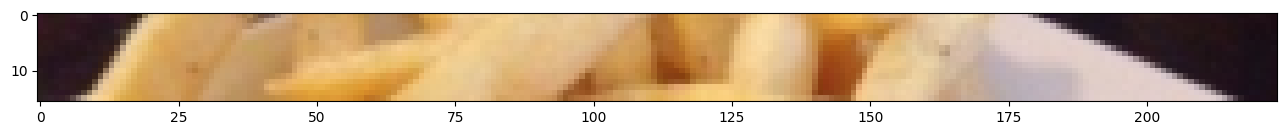

In [7]:
img_batch, label_batch = next(iter(train_dataloader))
image_permuted = img_batch[0].permute(1, 2, 0)
patch_size = 16

plt.figure(figsize=(patch_size, patch_size))
plt.imshow(image_permuted[:patch_size, :, :])

In [8]:
# putting the conv2d -> flatten into a single nn.Sequential layer
class PatchEmbedding(nn.Module):
  def __init__(self,
               in_channels:int=3,
               out_channels:int=768,
               kernel_size:int=16,
               stride:int=16,
               padding:int=0,
               flatten_start_dim:int=2,
               flatten_end_dim:int=3):
    super().__init__()

    self.conv2d = nn.Conv2d(in_channels=in_channels,
                            out_channels=out_channels,
                            kernel_size=kernel_size,
                            stride=stride,
                            padding=padding)
    self.flatten = nn.Flatten(start_dim=flatten_start_dim, end_dim=flatten_end_dim)

  def forward(self, x):
    flattened_emb = self.flatten(self.conv2d(x))
    return flattened_emb.permute(0, 2, 1)

patch_embedding = PatchEmbedding()
flattened_embedding = patch_embedding(img_batch[0].unsqueeze(0))
flattened_embedding.shape

torch.Size([1, 196, 768])

In [9]:
class MSABlock(nn.Module):
  def __init__(self, embedding_dim:int=768, num_heads:int=12, dropout_rate:float=0.0):
    super().__init__()
    self.layerNorm = nn.LayerNorm(normalized_shape=embedding_dim)
    self.msa = nn.MultiheadAttention(embed_dim=embedding_dim, num_heads=num_heads, dropout=dropout_rate, batch_first=True)

  def forward(self, x):
    normalized_embedding = self.layerNorm(x)
    attn_output, _ = self.msa(query=normalized_embedding,
                              key=normalized_embedding,
                              value=normalized_embedding,
                              need_weights=False)

    return attn_output

In [10]:
class MLPBlock(nn.Module):
  def __init__(self, patch_embedding_size:int=768, mlp_size:int=3072, dropout_rate:float=0.1):
    super().__init__()
    self.layerNorm = nn.LayerNorm(normalized_shape=patch_embedding_size)
    self.mlp = nn.Sequential(
      nn.Linear(in_features=patch_embedding_size, out_features=mlp_size),
      nn.GELU(),
      nn.Dropout(p=dropout_rate),
      nn.Linear(in_features=mlp_size, out_features=patch_embedding_size),
      nn.Dropout(p=dropout_rate)
    )

  def forward(self, x):
    normalized_emb = self.layerNorm(x)
    return self.mlp(normalized_emb)

In [11]:
class TransformerEncoderBlock(nn.Module):
  def __init__(self,
               patch_embedding_size:int=768,
               msa_num_heads:int=12,
               msa_dropout_rate:float=0.0,
               mlp_size:int=3072,
               mlp_dropout_rate:float=0.1):
    super().__init__()

    self.msa_block = MSABlock(embedding_dim=patch_embedding_size, num_heads=msa_num_heads, dropout_rate=msa_dropout_rate)
    self.mlp_block = MLPBlock(patch_embedding_size=patch_embedding_size, mlp_size=mlp_size, dropout_rate=mlp_dropout_rate)

  def forward(self, x):
    x = self.msa_block(x) + x
    x = self.mlp_block(x) + x

    return x

In [27]:
class ViT(nn.Module):
  def __init__(self,
               img_size:int=224,
               in_channels:int=3,
               patch_size:int=16,
               embedding_dim:int=768,
               embedding_dropout_rate=0.1,
               num_transformer_layers:int=12,
               num_msa_heads:int=12,
               msa_dropout_rate:float=0.0,
               mlp_size=3072,
               mlp_dropout_rate=0.1,
               num_classes=1000):
    super().__init__()

    assert img_size % patch_size == 0, f"Image size must be divisible by patch size, image size: {img_size}, patch size: {patch_size}."

    # splitting the image into patches
    self.num_patches = (img_size * img_size) // (patch_size * patch_size)
    self.cls_token = nn.Parameter(torch.randn((1, 1, embedding_dim)))
    self.positional_embedding = nn.Parameter(torch.randn((self.num_patches + 1, embedding_dim)))

    self.embedding_dropout = nn.Dropout(p=embedding_dropout_rate)

    self.patch_embedding = PatchEmbedding(in_channels=in_channels,
                                          out_channels=embedding_dim,
                                          kernel_size=patch_size,
                                          stride=patch_size)

    # initializing 12 layers of the transformer encoder
    self.transformer_encoder = nn.Sequential(*[TransformerEncoderBlock(patch_embedding_size=embedding_dim,
                                                       msa_num_heads=num_msa_heads,
                                                       msa_dropout_rate=msa_dropout_rate,
                                                       mlp_size=mlp_size,
                                                       mlp_dropout_rate=mlp_dropout_rate) for _ in range(num_transformer_layers)])

    # final mlp head
    self.mlp_head = nn.Sequential(
        nn.LayerNorm(normalized_shape=embedding_dim),
        nn.Linear(in_features=embedding_dim, out_features=num_classes)
    )

  def forward(self, x):
    batch_size = x.shape[0]

    class_token = self.cls_token.expand(batch_size, -1, -1)
    x = self.patch_embedding(x)
    x = torch.cat((class_token, x), dim=1)
    x = x + self.positional_embedding
    x = self.embedding_dropout(x)

    x = self.transformer_encoder(x)
    x = self.mlp_head(x[:, 0])

    return x

In [28]:
# summary of entire ViT module
vit = ViT()
summary(model=vit,
        input_size=(32, 3, 224, 224), # (batch_size, color_channels, height, width)
        # col_names=["input_size"], # uncomment for smaller output
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                       Input Shape          Output Shape         Param #              Trainable
ViT (ViT)                                     [32, 3, 224, 224]    [32, 1000]           152,064              True
├─PatchEmbedding (patch_embedding)            [32, 3, 224, 224]    [32, 196, 768]       --                   True
│    └─Conv2d (conv2d)                        [32, 3, 224, 224]    [32, 768, 14, 14]    590,592              True
│    └─Flatten (flatten)                      [32, 768, 14, 14]    [32, 768, 196]       --                   --
├─Dropout (embedding_dropout)                 [32, 197, 768]       [32, 197, 768]       --                   --
├─Sequential (transformer_encoder)            [32, 197, 768]       [32, 197, 768]       --                   True
│    └─TransformerEncoderBlock (0)            [32, 197, 768]       [32, 197, 768]       --                   True
│    │    └─MSABlock (msa_block)              [32, 197, 768]       [32, 197, 768]      

In [29]:
# training loop
from going_modular.going_modular import engine

optimizer = torch.optim.Adam(params=vit.parameters(),
                             lr=3e-3,
                             betas=(0.9, 0.999),
                             weight_decay=0.3)

loss_fn = torch.nn.CrossEntropyLoss()

results = engine.train(model=vit,
                       train_dataloader=train_dataloader,
                       test_dataloader=test_dataloader,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs=10,
                       device=device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 2.1951 | train_acc: 0.3086 | test_loss: 2.3340 | test_acc: 0.5417
Epoch: 2 | train_loss: 1.6234 | train_acc: 0.4180 | test_loss: 5.1594 | test_acc: 0.1979
Epoch: 3 | train_loss: 1.8620 | train_acc: 0.3047 | test_loss: 1.2301 | test_acc: 0.5417
Epoch: 4 | train_loss: 1.3678 | train_acc: 0.4180 | test_loss: 1.0849 | test_acc: 0.5417
Epoch: 5 | train_loss: 1.2397 | train_acc: 0.3008 | test_loss: 1.0880 | test_acc: 0.5417
Epoch: 6 | train_loss: 1.2016 | train_acc: 0.2812 | test_loss: 1.5398 | test_acc: 0.1979
Epoch: 7 | train_loss: 1.2818 | train_acc: 0.2695 | test_loss: 1.0527 | test_acc: 0.5417
Epoch: 8 | train_loss: 1.3075 | train_acc: 0.2930 | test_loss: 1.5971 | test_acc: 0.1979
Epoch: 9 | train_loss: 1.3045 | train_acc: 0.4180 | test_loss: 1.2426 | test_acc: 0.2604
Epoch: 10 | train_loss: 1.3317 | train_acc: 0.2734 | test_loss: 1.1071 | test_acc: 0.5417


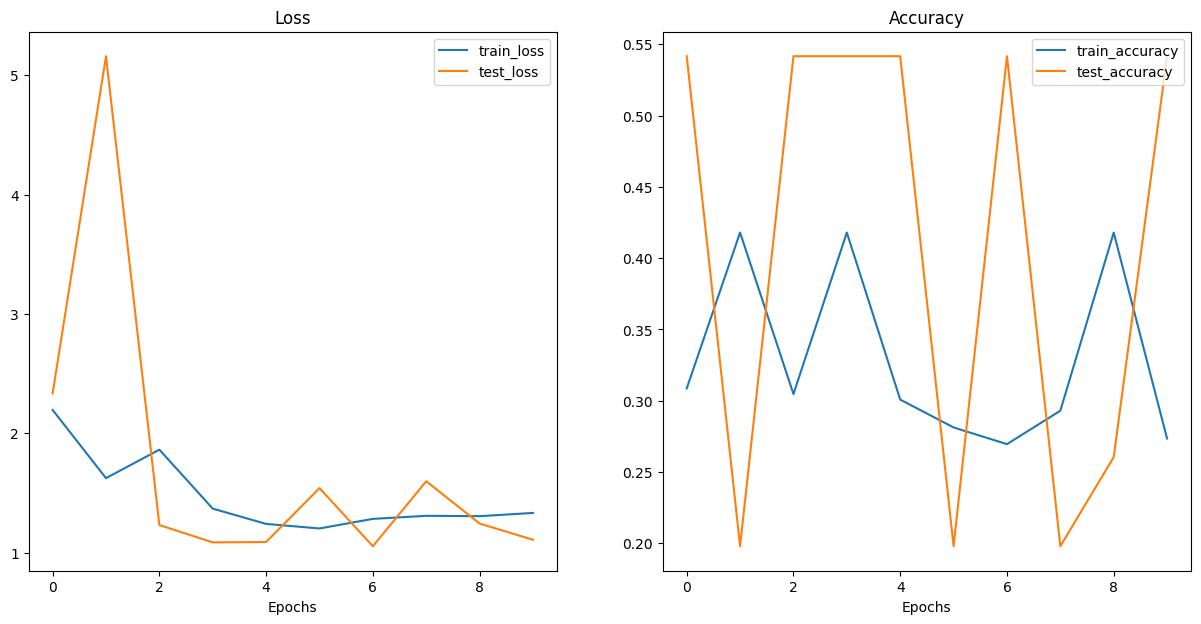

In [30]:
from helper_functions import plot_loss_curves

plot_loss_curves(results)